# Debt-Ceiling — is the brinkmanship a volatility trade? 🪙
### Does fear-vol ramp into the deadline and collapse when Washington blinks? In plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Is_brinkmanship_a_vol_trade%3F: Busted](https://img.shields.io/badge/Is_brinkmanship_a_vol_trade%3F-Busted-8b949e?style=flat-square)

Every time the US flirts with not paying its bills, the trading desks dust off the same playbook: **buy volatility into the debt-ceiling deadline** (the market's fear is supposed to build as the 'X-date' approaches), then **sell it the moment Congress blinks** (relief, vol collapses). It *sounds* like a sure thing. This notebook asks the only question that matters: **does the VIX actually do that?**

> **This is the plain-language layer.** Want the *t*-stats, the random-date placebo and the carry-tax math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/, _cache/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from debt_ceiling import data, strategy as st

PRE, POST = 20, 20

def _have_cache():
    return os.path.exists(data._cache_path("^VIX"))

HAVE_REAL = _have_cache()

def load_vix():
    return data.load_real("^VIX", end="2026-05-31")

print("real VIX cache present:", HAVE_REAL)


real VIX cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does vol *rise* into the deadline? | **No.** Across 7 brink-going episodes the VIX actually *fell* 5% on average into the deadline — only **2 of 7** rose. |
| Does vol *collapse* on resolution? | **No** — if anything it drifted *up* afterward, and that's carried almost entirely by **2011** (the spike came *after* the deal, on a credit downgrade). |
| Is it different from a random week? | **No.** The debt-ceiling windows are statistically indistinguishable from random dates (*p* ≈ 0.5). |
| Could you trade it? | **No.** The long-vol-into / short-vol-out round-trip *loses* ~10% per event — because waiting long-vol for the deadline bleeds you the carry tax every single day. |

> The 'debt-ceiling vol trade' is a story built on one scary episode (2011) that didn't even fit the trade — the vol spiked *after* the deal. With seven events total, there's nothing here to trade.

## 1 · The claim

> *"As the debt-ceiling X-date approaches, hedging demand drives implied volatility up — markets price a (tiny but real) chance the US technically defaults. The moment a deal is struck, that fear evaporates and vol collapses. So you go **long vol into the deadline** and **short vol on resolution**."*

— the standard derivatives-desk 'how to trade the debt ceiling' note (Goldman, JPMorgan, BofA; echoed across CNBC/Bloomberg)

It's a clean, intuitive story: anxiety builds, then relief. The VIX — the market's 'fear gauge' — should trace a neat little hump, peaking right at the deadline.

## 2 · So what?

Two reasons to care. First, if it were true it'd be a *calendar-known* trade — the X-date is announced weeks ahead, so you'd have a rare thing: a volatility event you can see coming. Second, this is the **volatility** cousin of the desk's [shutdown 'buy the dip' study](../../311-government-shutdown/): one asks *do stocks bounce*, this one asks *does fear spike*. Testing both separates two different pieces of Washington folklore — and shows how a single dramatic episode can fool everyone into seeing a pattern.

## 3 · How would we even know?

Three checks keep us honest:

1. **Draw the hump.** Line up all 7 deadlines and plot the average VIX path around them. If the thesis is right, we see vol climb into day 0 and fall after.
2. **Compare to a random week.** A spike only means something if it's *bigger* than what the VIX does around any random date. So we measure the same windows around thousands of random dates and ask: is the debt-ceiling move unusual?
3. **Actually trade it — with the carry tax.** Holding a long-vol position isn't free: VIX futures roll *down* a usually-upward-sloping curve, so you bleed value every day you wait. We charge that and see if the trade survives.

Tape: the CBOE **VIX** daily level back to 1990. Seven brink-going episodes — and we'll say loudly that seven is far too few to call anything a strategy.

## 4 · The teardown — let's actually look

**First, the hump.** Here's the average VIX path around the seven deadlines (rebased to 1.0 at the deadline). If the story holds, it peaks in the middle.

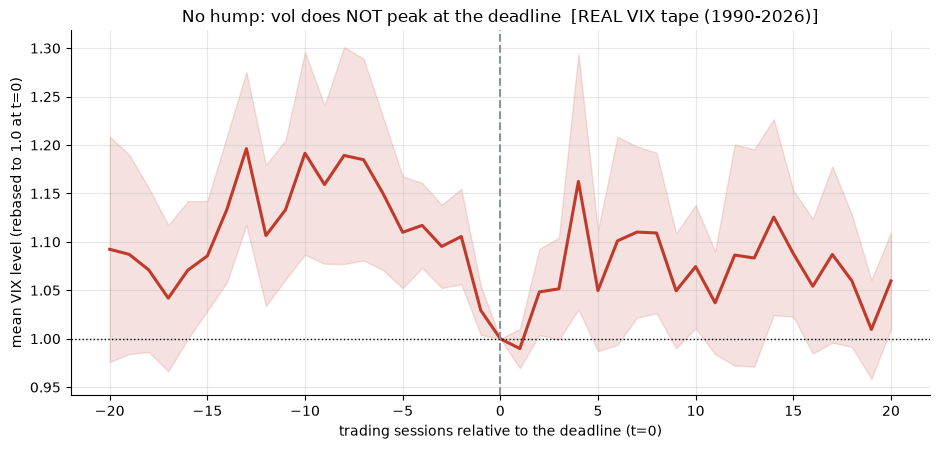

If the thesis were right this would be a tent peaking at 0. It is not.


In [2]:
if HAVE_REAL:
    vix = load_vix(); ev = data.deadlines()
    path = st.vix_path(vix, ev, pre=PRE, post=POST)
    banner = 'REAL VIX tape (1990-2026)'
else:
    b, ev, _ = data.synthetic_vix(event_effect=0.0, n_events=40, seed=314)
    path = st.vix_path(b, ev, pre=PRE, post=POST)
    banner = 'SYNTHETIC null tape (offline fallback)'
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(path.index, path['mean'], lw=2.2, color=RED)
ax.fill_between(path.index, path['mean']-path['se'], path['mean']+path['se'],
                color=RED, alpha=.15)
ax.axvline(0, ls='--', c=GREY); ax.axhline(1.0, ls=':', c='k', lw=1)
ax.set_xlabel('trading sessions relative to the deadline (t=0)')
ax.set_ylabel('mean VIX level (rebased to 1.0 at t=0)')
ax.set_title(f'No hump: vol does NOT peak at the deadline  [{banner}]')
plt.tight_layout(); plt.show()
print('If the thesis were right this would be a tent peaking at 0. It is not.')

No hump. On the real tape the VIX **fell ~5%** into the deadline on average — the opposite of 'fear builds.' The neat little anxiety-then-relief shape simply isn't there.

**Second, the per-event detail — where does the 'vol spike' story even come from?** Here's each episode's vol move *into* the deadline. Watch one bar carry the whole narrative:

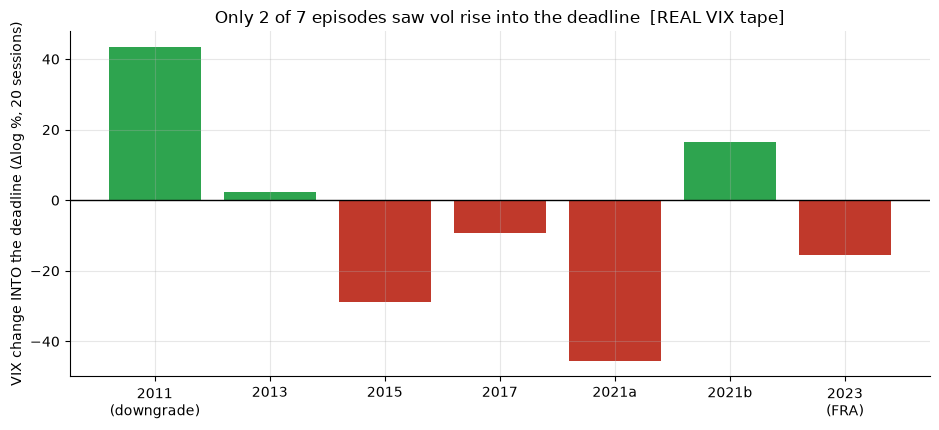

Mean across all 7: -5.2%  —  drop 2011 and it is strongly negative.


In [3]:
names = ['2011\n(downgrade)','2013','2015','2017','2021a','2021b','2023\n(FRA)']
if HAVE_REAL:
    pr = st.pre_ramp(vix, ev, pre=PRE)
    pre_vals = (pr['d_log']*100).to_numpy()
    banner = 'REAL VIX tape'
else:
    pre_vals = np.array([43.4, 2.4, -28.8,
        -9.2, -45.5, 16.4, -15.4])
    banner = 'frozen real numbers (docs/results.md)'
fig, ax = plt.subplots(figsize=(9.5, 4.4))
cols = [GREEN if v > 0 else RED for v in pre_vals]
ax.bar(names, pre_vals, color=cols)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('VIX change INTO the deadline (Δlog %, 20 sessions)')
ax.set_title(f'Only 2 of 7 episodes saw vol rise into the deadline  [{banner}]')
plt.tight_layout(); plt.show()
print(f'Mean across all 7: {pre_vals.mean():+.1f}%  —  drop 2011 and it is strongly negative.')

There it is. **Five of the seven episodes saw vol *fall* into the deadline.** The only real 'spike' is **2011** — and even that one mostly happened *after* the deal was signed, when S&P downgraded US debt from AAA. That's not the trade; that's a separate credit shock that happened to land nearby.

**Third: is any of this different from a random week?** The honest test. We measure the same window around thousands of random dates and compare:

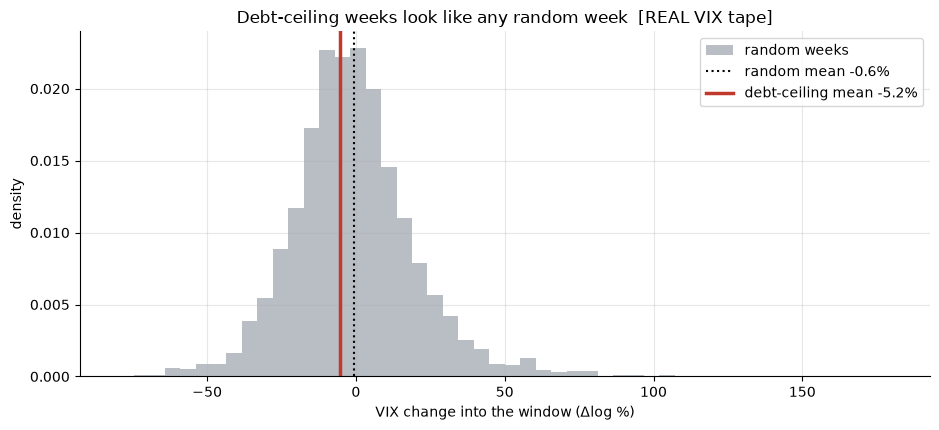

The red line sits right inside the grey cloud — nothing special is happening.


In [4]:
if HAVE_REAL:
    rng = np.random.default_rng(312); n = len(vix)
    idx = np.arange(PRE+5, n-POST-5)
    rlocs = rng.choice(idx, size=3000, replace=False)
    rand_pre = st.window_log_changes(vix, rlocs, PRE, 'pre')*100
    ev_pre = (st.pre_ramp(vix, ev, pre=PRE)['d_log']*100).to_numpy()
    banner = 'REAL VIX tape'
else:
    rng = np.random.default_rng(312)
    rand_pre = rng.normal(-0.6, 15, 3000)
    ev_pre = np.array([43.4, 2.4, -28.8,
        -9.2, -45.5, 16.4, -15.4])
    banner = 'synthetic fallback'
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.hist(rand_pre, bins=50, color=GREY, alpha=.6, density=True, label='random weeks')
ax.axvline(rand_pre.mean(), color='k', ls=':', label=f'random mean {rand_pre.mean():+.1f}%')
ax.axvline(ev_pre.mean(), color=RED, lw=2.5, label=f'debt-ceiling mean {ev_pre.mean():+.1f}%')
ax.set_xlabel('VIX change into the window (Δlog %)'); ax.set_ylabel('density')
ax.set_title(f'Debt-ceiling weeks look like any random week  [{banner}]'); ax.legend()
plt.tight_layout(); plt.show()
print('The red line sits right inside the grey cloud — nothing special is happening.')

The debt-ceiling average (red) sits comfortably inside the random-date cloud. The formal placebo test agrees: permutation *p* ≈ 0.55. There is **no abnormal vol behaviour** to bank — debt-ceiling weeks are just... weeks.

## 5 · The verdict

- **Signal — None.** Vol *fell* ~5% into the deadline (only 2/7 episodes positive), didn't collapse after, and is indistinguishable from random dates (*p* ≈ 0.55). Seven events is far too few regardless.
- **Tradability — Mirage.** The long-vol-into / short-vol-out round-trip *loses* ~10% per event before costs — the long-vol carry tax bleeds you while you wait, and the vol move never shows up to pay you back.
- **Is brinkmanship a vol trade? — Busted.** The whole narrative is one episode (2011) that spiked *after* the deal on a credit downgrade — the opposite of the trade.

## 6 · Could you actually trade it?

Here's the part the playbook never mentions: **holding long volatility costs you money every day**, deal or no deal. VIX futures usually roll *down* a hill, so a long-vol position bleeds — the 'carry tax.' Watch what it does to the trade:

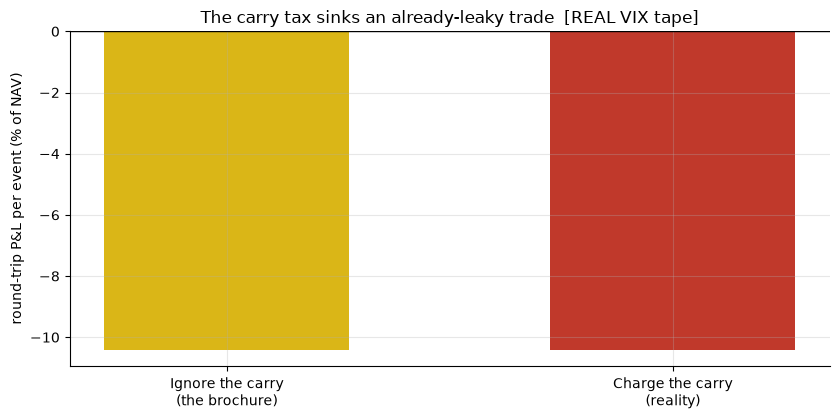

Even ignoring carry it barely works; charging it: -10.4% per event.


In [5]:
if HAVE_REAL:
    rt0 = st.vol_round_trip(vix, ev, pre=PRE, post=POST, daily_carry_bps=0.0)
    rtc = st.vol_round_trip(vix, ev, pre=PRE, post=POST, daily_carry_bps=25.0)
    no_carry = rt0['pnl_gross'].mean()*100; with_carry = rtc['pnl_gross'].mean()*100
    banner = 'REAL VIX tape'
else:
    no_carry, with_carry = -0.4, -10.4
    banner = 'frozen real numbers'
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar(['Ignore the carry\n(the brochure)','Charge the carry\n(reality)'],
           [no_carry, with_carry], color=[AMBER, RED], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('round-trip P&L per event (% of NAV)')
ax.set_title(f'The carry tax sinks an already-leaky trade  [{banner}]')
plt.tight_layout(); plt.show()
print(f'Even ignoring carry it barely works; charging it: {with_carry:+.1f}% per event.')

Even *ignoring* the carry the trade is marginal — because the vol move the thesis needs isn't there. Charge the real ~25-bps/day roll and it's a clear **loser (~10% per event)**. Unlike a 'real but fragile' edge, there's nothing underneath here to rescue. It's a mirage.

## 7 · Going further

- **The directional sibling.** [Study 311 — Government-Shutdown](../../311-government-shutdown/) asks *do stocks bounce* around fiscal cliffs (also a weak/mirage result). Together they cover both halves of 'trading Washington.'
- **Was 2011 special?** Arguably the only debt-ceiling episode that genuinely scared markets — and the fear came from the **S&P downgrade**, a credit event, not the deadline itself. A fun fork: re-run excluding 2011 and watch the (already absent) signal vanish entirely.
- **Could a *shorter* window catch a last-minute spike?** Try pre=5 instead of 20 — the vol still doesn't reliably ramp, but it's the natural next robustness check.

*Think there's a debt-ceiling vol trade hiding in a different window or instrument? Fork this, change `PRE`/`POST` or swap the VIX for VIX futures, and show the spike surviving a random-date placebo on more than one episode.*